# Geopandas
- open source project used to work with geospatial data within pandas
- docs: geopandas.org
- has a few dependancies
    - pandas
    - matplotlib; plotting & visualizations
    - shapely; geometrical operations(objects and functions, manipulating lines, points and polygons)
    - descartes; integrate matplotlib with shapely
    - fiona; acts as a wrapper to read other datasets into geodatasets e.g. shapefiles, vectors etc.
    - pyproj; transformations and projections (mapping the globe onto a 2D plane), using epsg codes (crs) etc.

## Spatial Data
- raster data; uses grids and pixels (using textures) e.g. satellite imagery, lidar, elevation models using contours
- vector data;
    - points; has a tongitude and latitude
    - lines; connection btn any two points
    - polygons/faces

### Raster
- structures include:
    - elevation models

### Vector data
- structures include:
    - sdc (smart data compression)
    - shp (shapefile)
    - gdb ()

## CRS(Coordinate Reference System) System
- Depending on some EPSG code(European Petroleum Survey Group) epsg.io, some datasets are stored in formats that are useful for different functions e.g. aggregations, visualisations, integrationetc.
- Workflow:
    1. Check data and see what code it is set in
    2. If goal is different, set code to other code e.g.
        a. 4326 (WSG 84) for global coordinates
        b. 3857 (Web Mercator) for web maps
    3. proceed with analysis

# Prep

In [36]:
import geopandas as gpd
from geodatasets import get_path
import matplotlib.pyplot as plt

In [37]:
gpd.__version__

'1.1.2'

## New York Boroughs

In [3]:
path_to_data = get_path("nybb")
gdf = gpd.read_file(path_to_data)

gdf

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


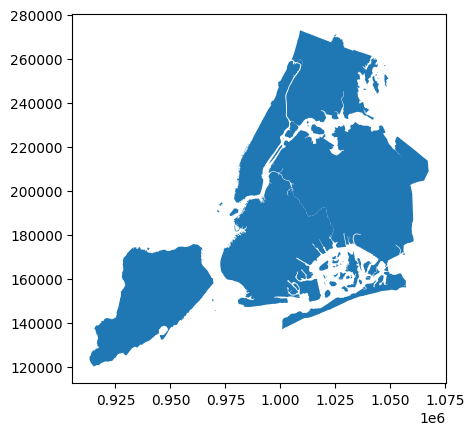

In [4]:
gdf.plot()      # matches when you search for new york on gmaps
plt.show()

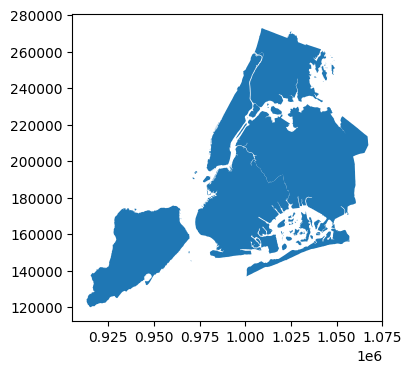

In [5]:
fig, ax = plt.subplots(figsize=(4,4))
gdf.plot(ax=ax) # map fills the figsize
plt.show()

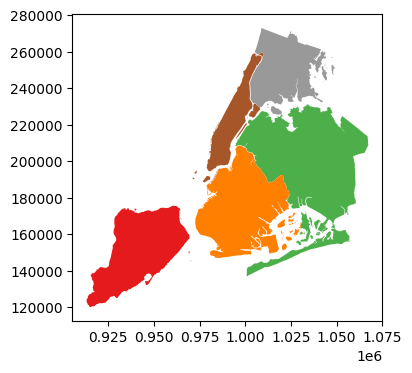

In [6]:
gdf.plot(figsize=(4,4),
         cmap='Set1')
plt.show()

In [7]:
# filtering by one borough, by creating a mask

staten_island = gdf[gdf['BoroName'] == 'Staten Island']

<Axes: >

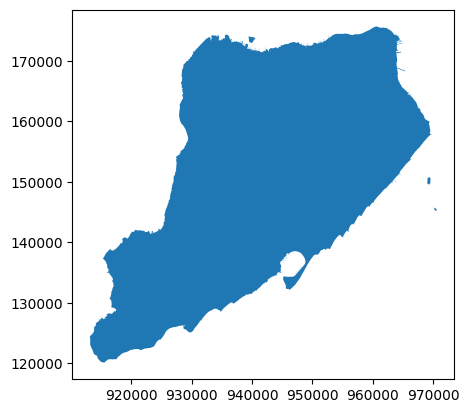

In [8]:
staten_island.plot()

In [9]:
from shapely.geometry import box

In [10]:
# shapely helps create a bounding box i.e. an intersection of 2 lats and 2 longs
# values all need to touch the polygons
# box(minx,maxx,miny,maxy)

bounding_box = box(930000,960000,130000,170000)

<Axes: >

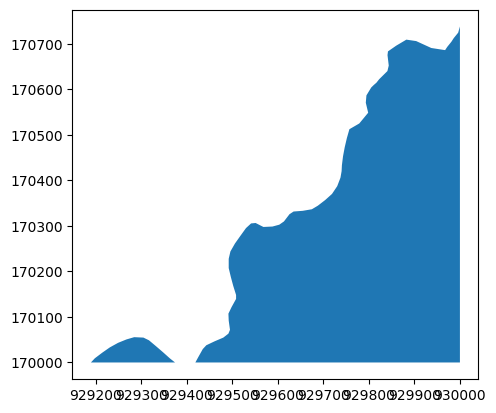

In [11]:
gdf.clip(bounding_box).plot()

## Barcelona: Sagrada Familia

In [12]:
url = 'https://raw.githubusercontent.com/jcanalesluna/bcn-geodata/master/districtes/districtes.geojson'

districts = gpd.read_file(url)

In [13]:
districts.head()

,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,...,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry
0,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,...,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((2.18345 41.39061, 2.18459 41.38976, ..."
1,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,...,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((2.1869 41.40165, 2.18689 41.40087, 2..."
2,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,...,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((2.14824 41.37623, 2.14896 41.3..."
3,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,...,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((2.10342 41.4011, 2.10352 41.40109, 2..."
4,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,...,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((2.07313 41.43522, 2.07319 41.4..."


In [14]:
import pandas as pd

In [15]:
pd.set_option('display.max_columns',100)    # view all columns
districts.head()

,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,NIVELL,NDESCR_CA,NDESCR_ES,NDESCR_EN,TERME,DISTRICTE,BARRI,AEB,SEC_CENS,GRANBARRI,ZUA,AREA_I,LITERAL,PERIMETRE,AREA,ORD_REPRES,CODI_UA,TIPUS_UA,NOM,WEB1,WEB2,WEB3,DOCUMENTA,RANGESCALA,TIPUS_POL,GRUIX_ID,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry
0,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,01,-,-,-,-,-,-,01,21366.962,4.204931e+06,5,01,DISTRICTE,Ciutat Vella,http://www.bcn.cat/ciutatvella,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((2.18345 41.39061, 2.18459 41.38976, ..."
1,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,02,-,-,-,-,-,-,02,13931.644,7.464303e+06,5,02,DISTRICTE,Eixample,http://www.bcn.cat/eixample,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((2.1869 41.40165, 2.18689 41.40087, 2..."
2,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,03,-,-,-,-,-,-,03,46711.857,2.287985e+07,5,03,DISTRICTE,Sants-Montjuïc,http://www.bcn.cat/sants-montjuic,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((2.14824 41.37623, 2.14896 41.3..."
3,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,04,-,-,-,-,-,-,04,12551.602,6.010769e+06,5,04,DISTRICTE,Les Corts,http://www.bcn.cat/lescorts,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((2.10342 41.4011, 2.10352 41.40109, 2..."
4,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,05,-,-,-,-,-,-,05,35757.403,1.991557e+07,5,05,DISTRICTE,Sarrià-Sant Gervasi,http://www.bcn.cat/sarria-santgervasi,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((2.07313 41.43522, 2.07319 41.4..."


### CRS

<Axes: >

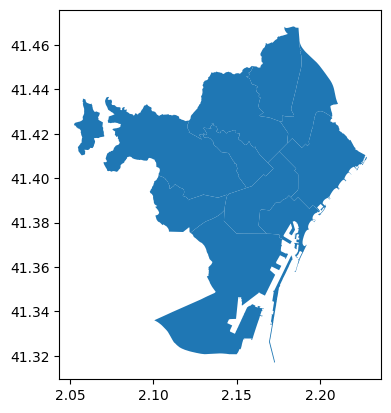

In [16]:
districts.plot()

In [17]:
# check crs system

districts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [18]:
# convert to 2062 (if needed)

new_districts = districts.to_crs(epsg=2062)
new_districts.crs

<Projected CRS: EPSG:2062>
Name: Madrid 1870 (Madrid) / Spain LCC
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Spain - mainland onshore.
- bounds: (-9.37, 35.95, 3.39, 43.82)
Coordinate Operation:
- name: Spain
- method: Lambert Conic Conformal (1SP)
Datum: Madrid 1870 (Madrid)
- Ellipsoid: Struve 1860
- Prime Meridian: Madrid

In [21]:
new_districts.head()

,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,NIVELL,NDESCR_CA,NDESCR_ES,NDESCR_EN,TERME,DISTRICTE,BARRI,AEB,SEC_CENS,GRANBARRI,ZUA,AREA_I,LITERAL,PERIMETRE,AREA,ORD_REPRES,CODI_UA,TIPUS_UA,NOM,WEB1,WEB2,WEB3,DOCUMENTA,RANGESCALA,TIPUS_POL,GRUIX_ID,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry
0,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,01,-,-,-,-,-,-,01,21366.962,4.204931e+06,5,01,DISTRICTE,Ciutat Vella,http://www.bcn.cat/ciutatvella,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090241.744 770405.596, 1090342.582 ..."
1,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,02,-,-,-,-,-,-,02,13931.644,7.464303e+06,5,02,DISTRICTE,Eixample,http://www.bcn.cat/eixample,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090448.237 771647.183, 1090453.694 ..."
2,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,03,-,-,-,-,-,-,03,46711.857,2.287985e+07,5,03,DISTRICTE,Sants-Montjuïc,http://www.bcn.cat/sants-montjuic,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1087409.714 768620.322, 108747..."
3,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,04,-,-,-,-,-,-,04,12551.602,6.010769e+06,5,04,DISTRICTE,Les Corts,http://www.bcn.cat/lescorts,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1083492.496 771129.964, 1083500.768 ..."
4,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,05,-,-,-,-,-,-,05,35757.403,1.991557e+07,5,05,DISTRICTE,Sarrià-Sant Gervasi,http://www.bcn.cat/sarria-santgervasi,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1080722.37 774743.807, 1080727..."


In [22]:
districts[['geometry']].iloc[0].to_list()

# used to inspect the geometry lats and longs to ID if usign the correct epsg code

[<POLYGON ((2.183 41.391, 2.185 41.39, 2.187 41.391, 2.187 41.391, 2.187 41.3...>]

### Area
Can only calc the area of a POLYGON, not a point e.g. the list above

In [23]:
districts['geometry'].area

C:\Users\HP\AppData\Local\Temp\ipykernel_19560\4240898824.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  districts['geometry'].area


0    0.000453
1    0.000804
2    0.002463
3    0.000647
4    0.002146
5    0.000455
6    0.001285
7    0.000869
8    0.000711
9    0.001125
dtype: float64

In [24]:
new_districts['area'] = new_districts['geometry'].area/1000000  # the division is to convert the default sq ms to sq kms

new_districts.head()

,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,NIVELL,NDESCR_CA,NDESCR_ES,NDESCR_EN,TERME,DISTRICTE,BARRI,AEB,SEC_CENS,GRANBARRI,ZUA,AREA_I,LITERAL,PERIMETRE,AREA,ORD_REPRES,CODI_UA,TIPUS_UA,NOM,WEB1,WEB2,WEB3,DOCUMENTA,RANGESCALA,TIPUS_POL,GRUIX_ID,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry,area
0,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,01,-,-,-,-,-,-,01,21366.962,4.204931e+06,5,01,DISTRICTE,Ciutat Vella,http://www.bcn.cat/ciutatvella,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090241.744 770405.596, 1090342.582 ...",4.200406
1,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,02,-,-,-,-,-,-,02,13931.644,7.464303e+06,5,02,DISTRICTE,Eixample,http://www.bcn.cat/eixample,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090448.237 771647.183, 1090453.694 ...",7.456303
2,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,03,-,-,-,-,-,-,03,46711.857,2.287985e+07,5,03,DISTRICTE,Sants-Montjuïc,http://www.bcn.cat/sants-montjuic,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1087409.714 768620.322, 108747...",22.854384
3,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,04,-,-,-,-,-,-,04,12551.602,6.010769e+06,5,04,DISTRICTE,Les Corts,http://www.bcn.cat/lescorts,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1083492.496 771129.964, 1083500.768 ...",6.004220
4,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,05,-,-,-,-,-,-,05,35757.403,1.991557e+07,5,05,DISTRICTE,Sarrià-Sant Gervasi,http://www.bcn.cat/sarria-santgervasi,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1080722.37 774743.807, 1080727...",19.894238


In [25]:
new_districts[['minx','miny','maxx','maxy']] = new_districts['geometry'].bounds

new_districts.head()

,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,NIVELL,NDESCR_CA,NDESCR_ES,NDESCR_EN,TERME,DISTRICTE,BARRI,AEB,SEC_CENS,GRANBARRI,ZUA,AREA_I,LITERAL,PERIMETRE,AREA,ORD_REPRES,CODI_UA,TIPUS_UA,NOM,WEB1,WEB2,WEB3,DOCUMENTA,RANGESCALA,TIPUS_POL,GRUIX_ID,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry,area,minx,miny,maxx,maxy
0,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,01,-,-,-,-,-,-,01,21366.962,4.204931e+06,5,01,DISTRICTE,Ciutat Vella,http://www.bcn.cat/ciutatvella,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090241.744 770405.596, 1090342.582 ...",4.200406,1.088630e+06,766775.874922,1.091640e+06,770572.184373
1,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,02,-,-,-,-,-,-,02,13931.644,7.464303e+06,5,02,DISTRICTE,Eixample,http://www.bcn.cat/eixample,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090448.237 771647.183, 1090453.694 ...",7.456303,1.086875e+06,768501.225940,1.090495e+06,772733.885980
2,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,03,-,-,-,-,-,-,03,46711.857,2.287985e+07,5,03,DISTRICTE,Sants-Montjuïc,http://www.bcn.cat/sants-montjuic,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1087409.714 768620.322, 108747...",22.854384,1.083720e+06,762200.011028,1.090443e+06,769628.877643
3,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,04,-,-,-,-,-,-,04,12551.602,6.010769e+06,5,04,DISTRICTE,Les Corts,http://www.bcn.cat/lescorts,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1083492.496 771129.964, 1083500.768 ...",6.004220,1.083075e+06,768376.338982,1.086968e+06,771130.819176
4,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,05,-,-,-,-,-,-,05,35757.403,1.991557e+07,5,05,DISTRICTE,Sarrià-Sant Gervasi,http://www.bcn.cat/sarria-santgervasi,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1080722.37 774743.807, 1080727...",19.894238,1.079068e+06,770005.676529,1.087893e+06,774897.073988


<Axes: >

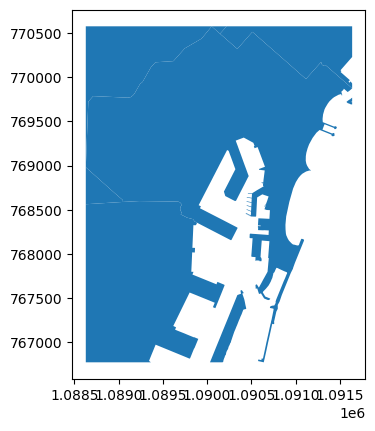

In [26]:
bounding_box = box(1088630,766776,1091640,770573)
new_districts.clip(bounding_box).plot()

### Centroid
most central point in the polygon

In [27]:
new_districts['centroid'] = new_districts['geometry'].centroid
new_districts.head()

,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,NIVELL,NDESCR_CA,NDESCR_ES,NDESCR_EN,TERME,DISTRICTE,BARRI,AEB,SEC_CENS,GRANBARRI,ZUA,AREA_I,LITERAL,PERIMETRE,AREA,ORD_REPRES,CODI_UA,TIPUS_UA,NOM,WEB1,WEB2,WEB3,DOCUMENTA,RANGESCALA,TIPUS_POL,GRUIX_ID,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry,area,minx,miny,maxx,maxy,centroid
0,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,01,-,-,-,-,-,-,01,21366.962,4.204931e+06,5,01,DISTRICTE,Ciutat Vella,http://www.bcn.cat/ciutatvella,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090241.744 770405.596, 1090342.582 ...",4.200406,1.088630e+06,766775.874922,1.091640e+06,770572.184373,POINT (1090083.871 769341.012)
1,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,02,-,-,-,-,-,-,02,13931.644,7.464303e+06,5,02,DISTRICTE,Eixample,http://www.bcn.cat/eixample,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090448.237 771647.183, 1090453.694 ...",7.456303,1.086875e+06,768501.225940,1.090495e+06,772733.885980,POINT (1088651.674 770409.974)
2,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,03,-,-,-,-,-,-,03,46711.857,2.287985e+07,5,03,DISTRICTE,Sants-Montjuïc,http://www.bcn.cat/sants-montjuic,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1087409.714 768620.322, 108747...",22.854384,1.083720e+06,762200.011028,1.090443e+06,769628.877643,POINT (1087284.958 765672.155)
3,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,04,-,-,-,-,-,-,04,12551.602,6.010769e+06,5,04,DISTRICTE,Les Corts,http://www.bcn.cat/lescorts,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1083492.496 771129.964, 1083500.768 ...",6.004220,1.083075e+06,768376.338982,1.086968e+06,771130.819176,POINT (1084830.283 769641.619)
4,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,05,-,-,-,-,-,-,05,35757.403,1.991557e+07,5,05,DISTRICTE,Sarrià-Sant Gervasi,http://www.bcn.cat/sarria-santgervasi,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1080722.37 774743.807, 1080727...",19.894238,1.079068e+06,770005.676529,1.087893e+06,774897.073988,POINT (1083668.091 772419.768)


### calc the distance from Sagrada Familia

In [28]:
from shapely.geometry import Point

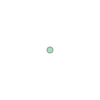

In [29]:
church = Point(2.1744, 41.4036)
church

In [30]:
# convert to geoseries

church_lat = gpd.GeoSeries(church, crs=4326)
church_lat

0    POINT (2.1744 41.4036)
dtype: geometry

In [31]:
# convert to projection crs system

church_projection = church_lat.to_crs(epsg=2062)
church_projection

0    POINT (1089392.299 771793.916)
dtype: geometry

In [32]:
new_districts['distance_from_sagrada'] = new_districts.apply(lambda row : row['centroid'].distance(church_projection), axis=1)/1000

new_districts.head()

,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,NIVELL,NDESCR_CA,NDESCR_ES,NDESCR_EN,TERME,DISTRICTE,BARRI,AEB,SEC_CENS,GRANBARRI,ZUA,AREA_I,LITERAL,PERIMETRE,AREA,ORD_REPRES,CODI_UA,TIPUS_UA,NOM,WEB1,WEB2,WEB3,DOCUMENTA,RANGESCALA,TIPUS_POL,GRUIX_ID,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry,area,minx,miny,maxx,maxy,centroid,distance_from_sagrada
0,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,01,-,-,-,-,-,-,01,21366.962,4.204931e+06,5,01,DISTRICTE,Ciutat Vella,http://www.bcn.cat/ciutatvella,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090241.744 770405.596, 1090342.582 ...",4.200406,1.088630e+06,766775.874922,1.091640e+06,770572.184373,POINT (1090083.871 769341.012),2.548532
1,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,02,-,-,-,-,-,-,02,13931.644,7.464303e+06,5,02,DISTRICTE,Eixample,http://www.bcn.cat/eixample,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1090448.237 771647.183, 1090453.694 ...",7.456303,1.086875e+06,768501.225940,1.090495e+06,772733.885980,POINT (1088651.674 770409.974),1.569657
2,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,03,-,-,-,-,-,-,03,46711.857,2.287985e+07,5,03,DISTRICTE,Sants-Montjuïc,http://www.bcn.cat/sants-montjuic,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1087409.714 768620.322, 108747...",22.854384,1.083720e+06,762200.011028,1.090443e+06,769628.877643,POINT (1087284.958 765672.155),6.474322
3,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,04,-,-,-,-,-,-,04,12551.602,6.010769e+06,5,04,DISTRICTE,Les Corts,http://www.bcn.cat/lescorts,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"POLYGON ((1083492.496 771129.964, 1083500.768 ...",6.004220,1.083075e+06,768376.338982,1.086968e+06,771130.819176,POINT (1084830.283 769641.619),5.044241
4,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,Límit de districte,ADM_02_PL,Límit de districte (polígon),Límite de distrito (polígono),District boundary (polygon),080193,05,-,-,-,-,-,-,05,35757.403,1.991557e+07,5,05,DISTRICTE,Sarrià-Sant Gervasi,http://www.bcn.cat/sarria-santgervasi,http://www.bcn.cat/estadistica/catala/dades/gu...,http://www.bcn.cat/estadistica/catala/document...,None,1-150000,None,6,70.0,0,Sòlid,0,0,1,Negre,#000000,Negre,#000000,"MULTIPOLYGON (((1080722.37 774743.807, 1080727...",19.894238,1.079068e+06,770005.676529,1.087893e+06,774897.073988,POINT (1083668.091 772419.768),5.758319


In [33]:
# distance from centroids to sagrada familia

new_districts['centroid'].distance(church_projection)

C:\Users\HP\AppData\Local\Temp\ipykernel_19560\1701380739.py:3: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  new_districts['centroid'].distance(church_projection)


0    2548.531606
1            NaN
2            NaN
3            NaN
4            NaN
5            NaN
6            NaN
7            NaN
8            NaN
9            NaN
dtype: float64

## Chicago population

In [38]:
import geodatasets

In [39]:
path = geodatasets.get_path("geoda.chicago_commpop")

Extracting 'chicago_commpop/chicago_commpop.geojson' from 'C:\Users\HP\AppData\Local\geodatasets\geodatasets\Cache\chicago_commpop.zip' to 'C:\Users\HP\AppData\Local\geodatasets\geodatasets\Cache\chicago_commpop.zip.unzip'


In [42]:
chicago = gpd.read_file(path)

chicago.head()

,community,NID,POP2010,POP2000,POPCH,POPPERCH,popplus,popneg,geometry
0,DOUGLAS,35,18238,26470,-8232,-31.099358,0,1,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,OAKLAND,36,5918,6110,-192,-3.142390,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,FULLER PARK,37,2876,3420,-544,-15.906433,0,1,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."
3,GRAND BOULEVARD,38,21929,28006,-6077,-21.698922,0,1,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
4,KENWOOD,39,17841,18363,-522,-2.842673,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ..."


In [43]:
chicago.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [47]:
new_chicago = chicago.to_crs(2062)

In [49]:
new_chicago['area'] = new_chicago['geometry'].area/1000000

new_chicago.head()

,community,NID,POP2010,POP2000,POPCH,POPPERCH,popplus,popneg,geometry,area
0,DOUGLAS,35,18238,26470,-8232,-31.099358,0,1,"MULTIPOLYGON (((-5381089.702 3848476.347, -538...",4.268228
1,OAKLAND,36,5918,6110,-192,-3.142390,0,1,"MULTIPOLYGON (((-5382750.607 3845522.312, -538...",1.569221
2,FULLER PARK,37,2876,3420,-544,-15.906433,0,1,"MULTIPOLYGON (((-5385890.95 3847000.293, -5385...",1.847789
3,GRAND BOULEVARD,38,21929,28006,-6077,-21.698922,0,1,"MULTIPOLYGON (((-5383472.432 3846491.757, -538...",4.498936
4,KENWOOD,39,17841,18363,-522,-2.842673,0,1,"MULTIPOLYGON (((-5382750.607 3845522.312, -538...",2.697131


In [51]:
# population per sq km

new_chicago['pop_per_sq_km'] = new_chicago['POP2010']/new_chicago['area']
new_chicago.head()

,community,NID,POP2010,POP2000,POPCH,POPPERCH,popplus,popneg,geometry,area,pop_per_sq_km
0,DOUGLAS,35,18238,26470,-8232,-31.099358,0,1,"MULTIPOLYGON (((-5381089.702 3848476.347, -538...",4.268228,4272.967597
1,OAKLAND,36,5918,6110,-192,-3.142390,0,1,"MULTIPOLYGON (((-5382750.607 3845522.312, -538...",1.569221,3771.296832
2,FULLER PARK,37,2876,3420,-544,-15.906433,0,1,"MULTIPOLYGON (((-5385890.95 3847000.293, -5385...",1.847789,1556.454895
3,GRAND BOULEVARD,38,21929,28006,-6077,-21.698922,0,1,"MULTIPOLYGON (((-5383472.432 3846491.757, -538...",4.498936,4874.263687
4,KENWOOD,39,17841,18363,-522,-2.842673,0,1,"MULTIPOLYGON (((-5382750.607 3845522.312, -538...",2.697131,6614.807667


<Axes: >

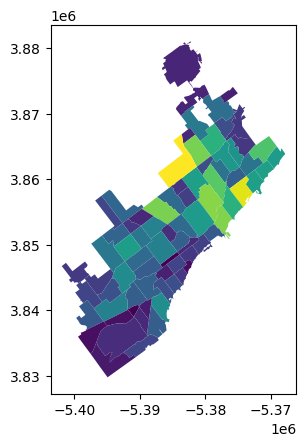

In [52]:
# choropleth of population in 2012

new_chicago.plot('POP2010')

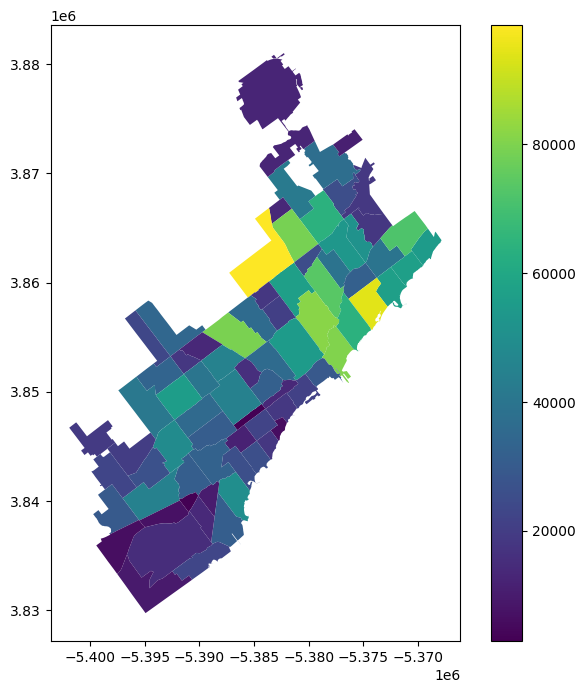

In [53]:
fig, ax = plt.subplots(figsize=(8,8))
new_chicago.plot('POP2010', ax=ax, legend=True)
plt.show()

In [63]:
new_chicago.describe()

,NID,POP2010,POP2000,POPCH,POPPERCH,popplus,popneg,area,pop_per_sq_km
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,39.000000,35007.766234,37610.597403,-2602.831169,-4.519802,0.220779,0.779221,7.770962,4978.372811
std,22.371857,22361.945576,24443.802619,5058.473127,20.513006,0.417492,0.417492,5.108726,2606.403936
min,1.000000,2876.000000,3294.000000,-19013.000000,-33.917831,0.000000,0.000000,1.569221,369.676757
25%,20.000000,18109.000000,18165.000000,-6017.000000,-14.167781,0.000000,1.000000,4.617658,3216.866942
50%,39.000000,31028.000000,33694.000000,-1596.000000,-8.630125,0.000000,1.000000,7.387564,4362.012997
75%,58.000000,48743.000000,52723.000000,-192.000000,-0.473544,0.000000,1.000000,9.170684,6416.938390
max,77.000000,98514.000000,117527.000000,12895.000000,124.944789,1.000000,1.000000,34.505821,12571.514175


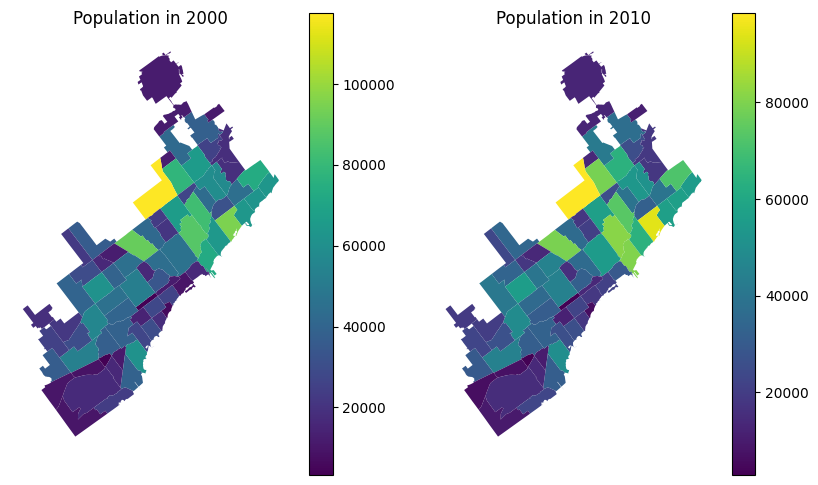

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,6),)

new_chicago.plot('POP2000', ax=ax[0], legend=True)
new_chicago.plot('POP2010', ax=ax[1], legend=True)

ax[0].set_title('Population in 2000')
ax[1].set_title('Population in 2010')

ax[0].set_axis_off()
ax[1].set_axis_off()

plt.show()

### both plots use the same scale

In [59]:
import numpy as np

In [71]:
pop2000 = np.array(new_chicago['POP2000'])
pop2010 = np.array(new_chicago['POP2010'])

pop_values = np.append(pop2000, pop2010)
pop_values

array([ 26470,   6110,   3420,  28006,  18363,  44574,  14146,  29920,
        27086,  63484,  25859,  18165,  18514,  57655,  65340,  58643,
        42164,  12646,  78144,  73199,  26908,  43083,  82715,  65836,
        87435, 117527,  23019,  20881,  46419,  41768,  63551,  91071,
        44031,   9509,  12032,  37669,  72811,  16388,  61556,  37275,
        11147,  38596,   3294,  15974,  52723,  31895,   8921,  16990,
        23653,  36649,   9809,   9781,  36101,  12644,  44912,  15962,
        94817,  33694,  51721,  15921,  39193,  22331,  29235,  61412,
        45282,  40222,  38619,  64320,  39584,  55928,  21992,  29843,
        18820,  25226,  11956,  62198,  11259,  18238,   5918,   2876,
        21929,  17841,  39493,  11717,  25681,  25983,  54991,  25448,
        18508,  17931,  51542,  64124,  53359,  41932,  13426,  78743,
        71942,  25010,  39262,  73595,  56323,  81432,  98514,  18001,
        20567,  54881,  35912,  56362,  79288,  35769,  21390,  13391,
      

In [72]:
min_pop = pop_values.min()
max_pop = pop_values.max()

print(min_pop, max_pop)

2876 117527


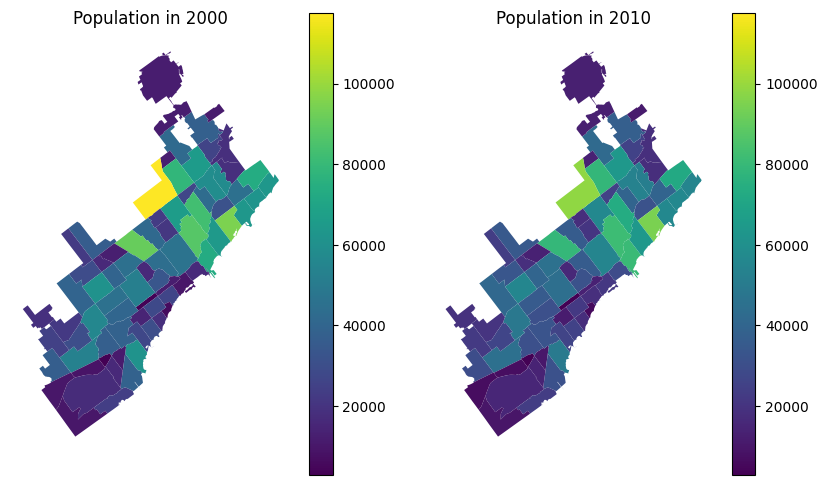

In [73]:
fig, ax = plt.subplots(1,2,figsize=(10,6),)

new_chicago.plot('POP2000', ax=ax[0], legend=True, vmax=max_pop, vmin=min_pop)
new_chicago.plot('POP2010', ax=ax[1], legend=True, vmax=max_pop, vmin=min_pop)

ax[0].set_title('Population in 2000')
ax[1].set_title('Population in 2010')

ax[0].set_axis_off()
ax[1].set_axis_off()

plt.show()

### showing missing values

<Axes: >

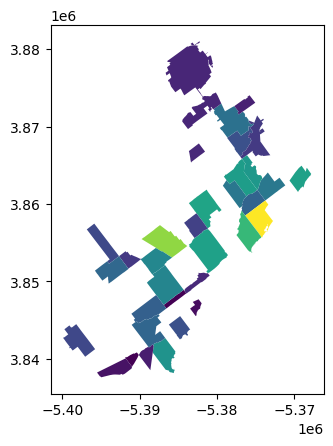

In [76]:
new_chicago.loc[np.random.choice(chicago.index, 30), 'POP2010'] = np.nan
new_chicago.plot(column='POP2010')

<Axes: >

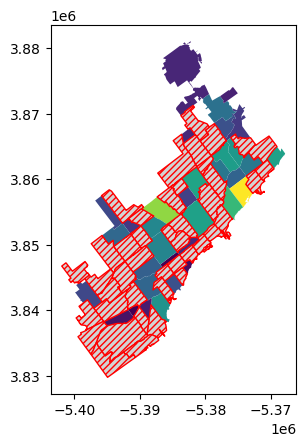

In [79]:
new_chicago.plot(column='POP2010', 
                missing_kwds={
                    "color": "lightgrey",
                    "edgecolor": "red",
                    "hatch": "/////",
                    "label": "Missing values",
                },
            )